# 09 - Gradient Boosting
**Fake News Detection using Machine Learning and NLP**

## Theory
Gradient Boosting builds an additive model in a stage-wise fashion.

## Step 1 - Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

sns.set_style('whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2 - Load Preprocessed Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/processed_fake_news_dataset.csv'

df = pd.read_csv(file_path)

## Step 3 - TF-IDF Vectorization

In [4]:
text_col = 'processed_text'
if text_col not in df.columns:
    text_col = 'content' if 'content' in df.columns else 'text'
df = df.dropna(subset=[text_col, 'label'])

tfidf = TfidfVectorizer(max_features=5000, max_df=0.7, min_df=2)
X = tfidf.fit_transform(df[text_col])
y = df['label'].values
print(f'TF-IDF matrix shape: {X.shape}')

TF-IDF matrix shape: (44685, 5000)


## Step 4 - Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'X_train: {X_train.shape}\nX_test: {X_test.shape}')

X_train: (35748, 5000)
X_test: (8937, 5000)


## Step 5 - Train Gradient Boosting Model

In [6]:
print('Training Gradient Boosting...')

model = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, subsample=0.8, random_state=42)

start = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start

print(f'Gradient Boosting training completed in {train_time:.2f}s')

Training Gradient Boosting...
Gradient Boosting training completed in 300.66s


## Step 6 - Predictions

In [7]:
y_pred = model.predict(X_test)
if hasattr(model, 'predict_proba'):
    y_prob = model.predict_proba(X_test)[:, 1]
elif hasattr(model, 'decision_function'):
    y_prob = model.decision_function(X_test)
else:
    y_prob = y_pred.astype(float)
print('Predictions generated!')

Predictions generated!


## Step 7 - Evaluation Metrics

In [8]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f'Training Time: {train_time:.2f}s')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Training Time: 300.66s

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4695
        Real       1.00      1.00      1.00      4242

    accuracy                           1.00      8937
   macro avg       1.00      1.00      1.00      8937
weighted avg       1.00      1.00      1.00      8937



## Step 8 - Confusion Matrix

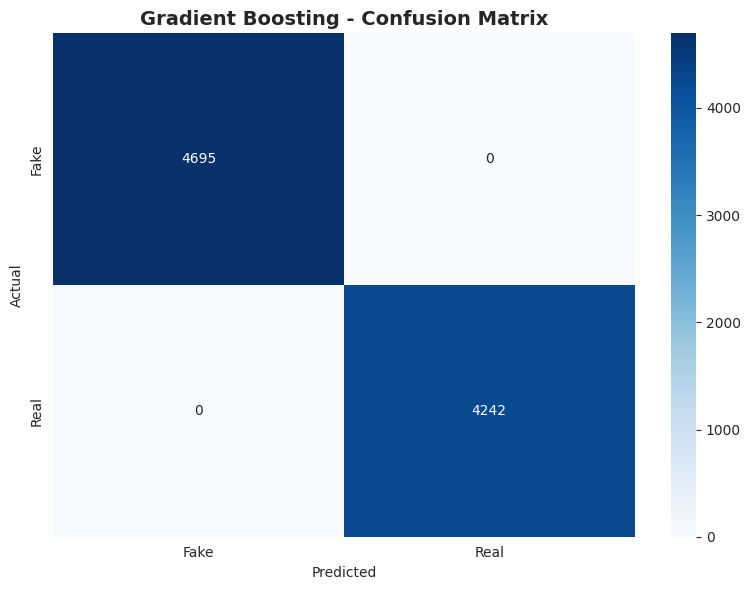

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Gradient Boosting - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Step 9 - ROC Curve

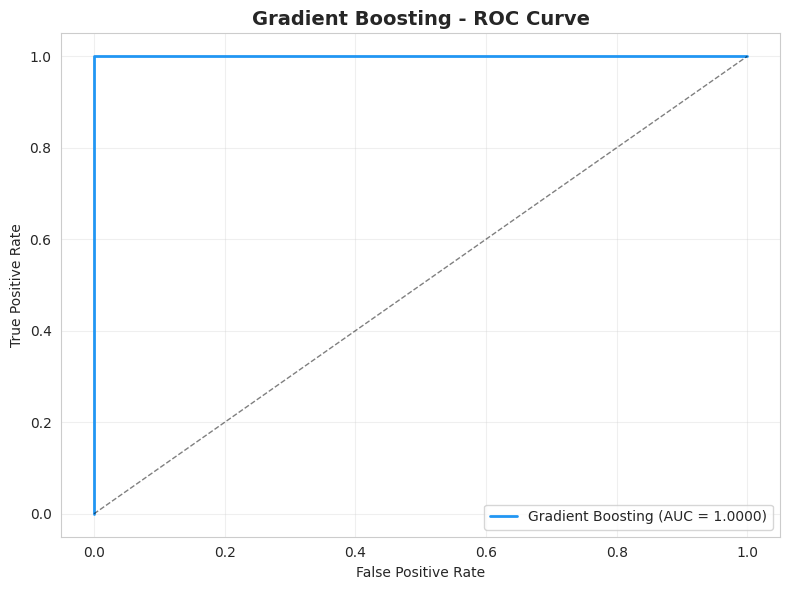

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2196F3', linewidth=2, label=f'Gradient Boosting (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Gradient Boosting - ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 10 - Save Model

In [11]:
# ==========================================================
# GRADIENT BOOSTING PIPELINE — TRAIN, SAVE & DOWNLOAD
# ==========================================================

from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from google.colab import files
import joblib


X_raw = df["processed_text"]
y = df["label"]


X_train_raw, X_test_raw, y_train, y_test = train_test_split(

    X_raw,
    y,

    test_size=0.2,
    random_state=42,
    stratify=y
)


gradient_boosting_pipeline = Pipeline([

    (
        "tfidf",

        TfidfVectorizer(
            max_features=5000,
            max_df=0.7,
            min_df=2
        )
    ),

    (
        "gradient_boosting",

        GradientBoostingClassifier(
            n_estimators=100,
            random_state=42
        )
    )
])


print("Training Gradient Boosting Pipeline...")

gradient_boosting_pipeline.fit(
    X_train_raw,
    y_train
)

print("Training Completed!")


model_name = "gradient_boosting_model.pkl"

joblib.dump(
    gradient_boosting_pipeline,
    model_name
)

print("Gradient Boosting Model Saved!")

files.download(model_name)

Training Gradient Boosting Pipeline...
Training Completed!
Gradient Boosting Model Saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>